In [95]:
# Tiến hành import thư viện để xử lí
import pandas as pd
import numpy as np
import json
from sqlalchemy import create_engine
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [96]:
engine = create_engine("sqlite:///../data/sample_strategy/sample_v4.db")

In [97]:
tables = ['cardiovascular_diseases', 'air_pollution', 'alcohol_consumption', 'BMI', 'cholesterol', 'diabetes', 'glucose', 'physical_activities', 'tobacco', 'country', 'time']

In [98]:
df = pd.read_sql('select * from NearsestSample where TimeDim >= 2010 AND SpatialDim = "VNM" order by TimeDim', engine)
df.drop(columns=['id', 'x7'], inplace=True)

In [99]:
df.columns = tables

In [100]:
df.head(n=50)

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,country,time
0,126.300000,1750.3900,55.657108,21.000000,4.3,5.200000,4.1,23.864973,3.2,VNM,2010
1,120.300000,55.9160,64.674275,21.100000,3.3,5.100000,4.8,18.590218,26.5,VNM,2010
2,36.800000,183.4050,42.246865,21.000000,1.0,5.100000,4.5,21.465141,49.7,VNM,2010
3,42.300000,93.0530,25.128159,0.581469,4.5,4.962720,4.3,20.197729,49.7,VNM,2010
4,32.300000,206.2990,44.336391,0.698844,3.2,4.820440,4.4,22.365805,49.7,VNM,2010
5,28.600000,511.1120,35.033364,21.124282,1.2,31.188297,4.8,23.100967,49.7,VNM,2010
6,25.000000,343.2590,41.818203,22.224012,4.4,28.428581,4.7,22.124281,49.7,VNM,2010
7,32.400000,327.8950,42.076280,21.599862,3.3,33.330435,4.7,20.823778,49.7,VNM,2010
8,22.867712,116.5560,41.476797,8.704425,1.1,5.100000,4.8,19.633612,49.7,VNM,2010
9,30.798542,1200.7630,54.385679,0.785277,3.3,5.100000,4.9,18.079346,49.7,VNM,2010


In [101]:
# Thử in mô tả dữ liệu
df.describe()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,75.000000,102.000000,102.000000,102.000000
mean,43.367638,9000.962505,45.009838,12.456560,2.928431,18.532618,4.757333,23.802695,32.527451,2014.264706
std,30.461136,75736.116005,14.404269,8.195601,1.420457,13.160934,0.223712,3.554938,15.009351,2.849097
min,22.471292,24.526000,1.942406,0.581469,1.000000,4.681230,4.100000,18.079346,1.500000,2010.000000
25%,26.413943,115.751250,39.555438,1.444769,1.125000,5.100000,4.700000,21.299416,24.200000,2012.000000
50%,32.350000,275.682000,42.076280,14.854485,3.400000,26.222596,4.800000,23.083139,24.200000,2014.000000
75%,42.750000,668.946250,55.869465,20.667224,4.400000,31.175307,4.900000,25.476875,49.700000,2017.000000
max,127.300000,763443.248700,65.669773,22.224012,4.700000,34.157610,5.000000,33.572872,49.700000,2019.000000


In [102]:
# Thử tiến hành bỏ qua các giá trị NULL
df.dropna(inplace=True)

In [103]:
df.describe()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000
mean,46.741692,10648.294236,46.658371,13.215539,2.846667,14.088746,4.757333,22.849359,32.632000,2012.920000
std,34.489523,88101.263460,12.441865,8.647135,1.410514,12.550578,0.223712,2.881004,15.349629,1.977987
min,22.535559,24.526000,21.151084,0.581469,1.000000,4.681230,4.100000,18.079346,2.200000,2010.000000
25%,26.621524,144.267000,41.564109,1.198562,1.100000,5.050000,4.700000,20.728701,24.200000,2011.000000
50%,32.400000,301.025000,42.246865,17.346087,3.300000,5.200000,4.800000,22.365805,24.200000,2013.000000
75%,43.350000,690.283500,55.869465,21.200000,4.400000,28.389299,4.900000,24.929430,49.700000,2015.000000
max,127.300000,763443.248700,65.669773,22.224012,4.600000,34.061864,5.000000,29.853064,49.700000,2016.000000


In [104]:
# Thử in lại một số điểm đầu của dữ liệu
df.head().T

,0,1,2,3,4
cardiovascular_diseases,126.3,120.3,36.8,42.3,32.3
air_pollution,1750.39,55.916,183.405,93.053,206.299
alcohol_consumption,55.657108,64.674275,42.246865,25.128159,44.336391
BMI,21.0,21.1,21.0,0.581469,0.698844
cholesterol,4.3,3.3,1.0,4.5,3.2
diabetes,5.2,5.1,5.1,4.96272,4.82044
glucose,4.1,4.8,4.5,4.3,4.4
physical_activities,23.864973,18.590218,21.465141,20.197729,22.365805
tobacco,3.2,26.5,49.7,49.7,49.7
country,VNM,VNM,VNM,VNM,VNM


In [105]:
def draw_histogram(column):
    var = df[column]
    plt.figure(figsize=(6, 4))
    sns.histplot(var, kde=True)
    plt.title(f"Phân phối dữ liệu của {column}")
    plt.ylabel("Số lượng")
    plt.xlabel("Biên độ giá trị")
    plt.show()

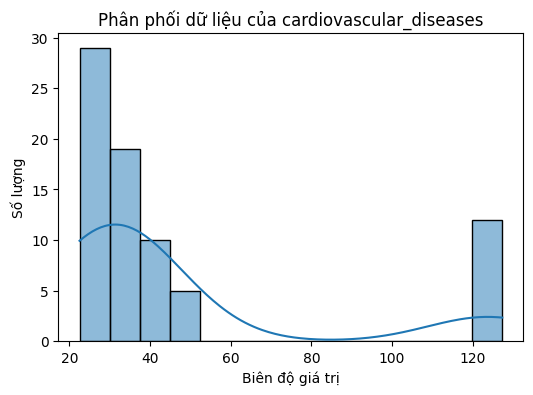

In [106]:
draw_histogram('cardiovascular_diseases')

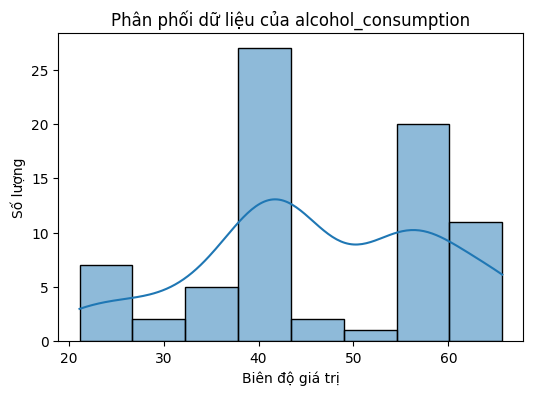

In [107]:
draw_histogram('alcohol_consumption')

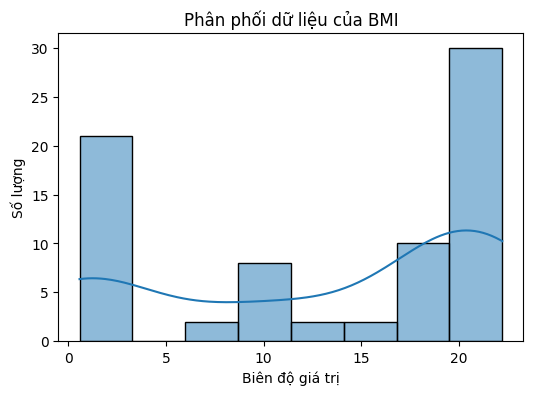

In [108]:
draw_histogram('BMI')

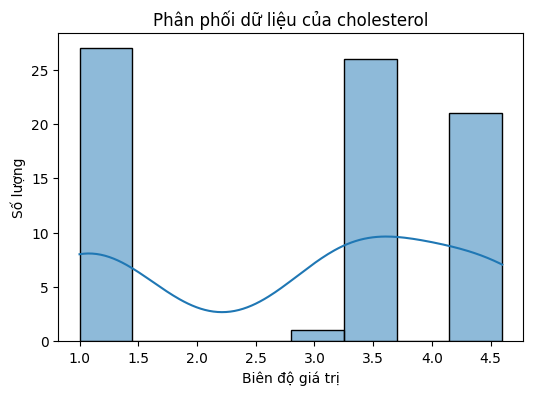

In [109]:
draw_histogram('cholesterol')

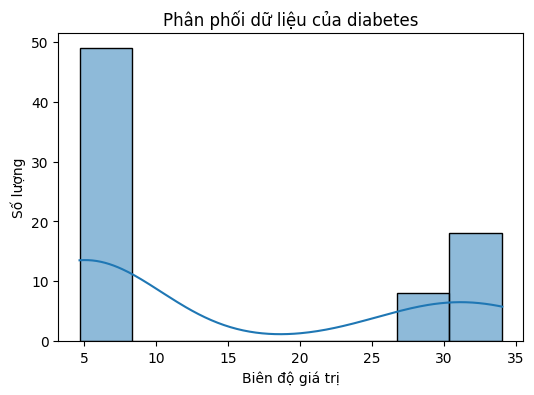

In [110]:
draw_histogram('diabetes')

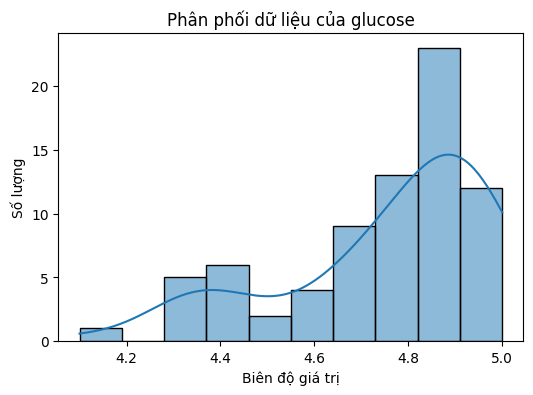

In [111]:
draw_histogram('glucose')

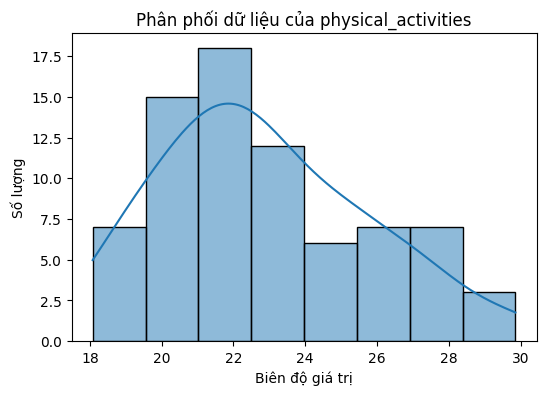

In [112]:
draw_histogram('physical_activities')

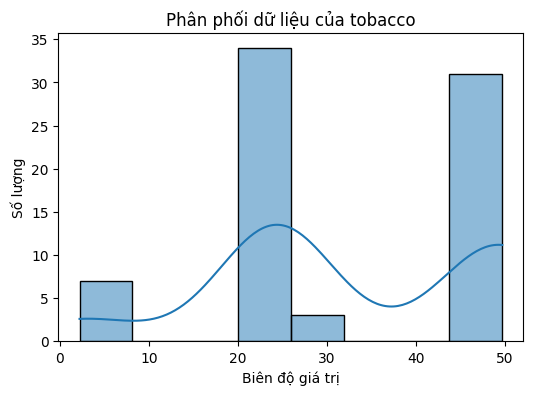

In [113]:
draw_histogram('tobacco')

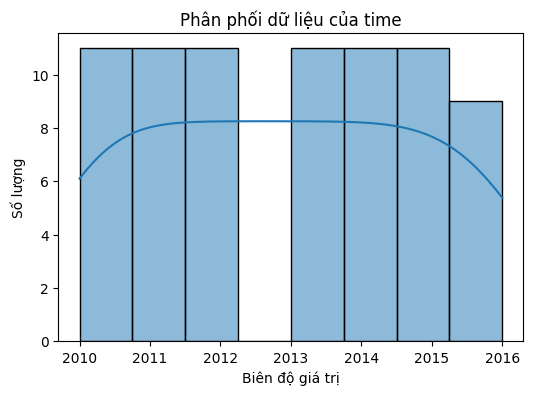

In [114]:
draw_histogram('time')

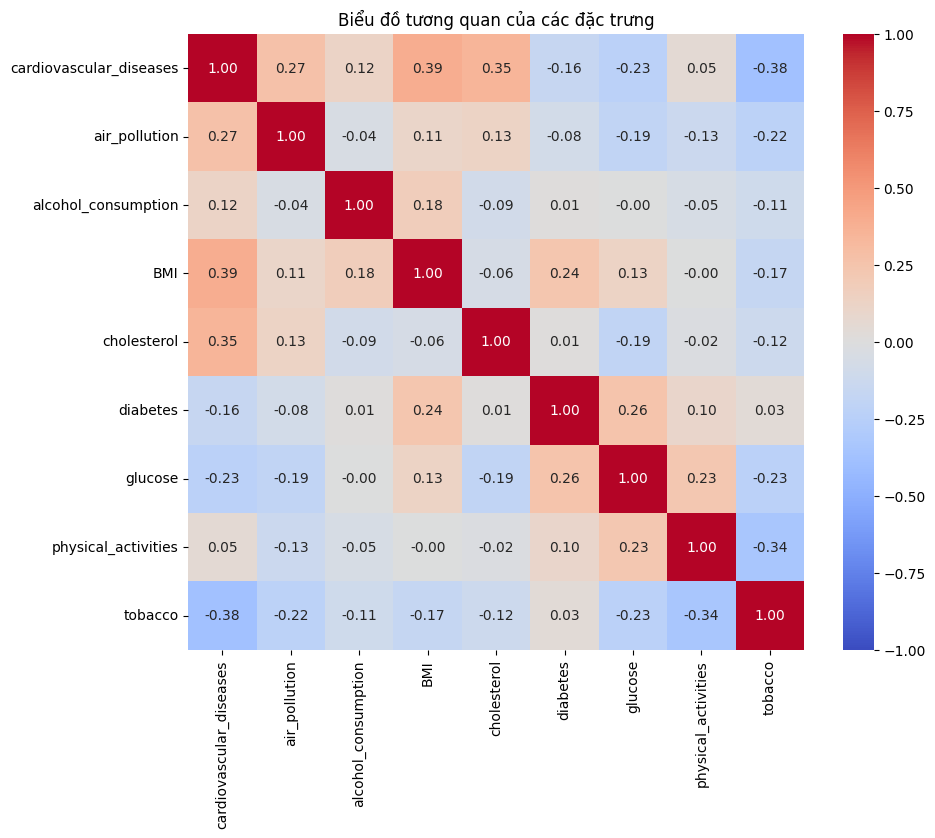

In [115]:
# Thử vẽ ma trận tương quan dữ liệu
# Diabetes là cột dữ liệu về kiểm soát nồng độ nên nó có tương quan âm với các thành phần còn lại
vars = tables.copy()
vars.pop()
vars.pop()

corr = df[vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        # hiện giá trị corr
    fmt=".2f",
    cmap="coolwarm",   # thang màu phổ biến cho corr
    vmin=-1, vmax=1,
    square=True
)
plt.title("Biểu đồ tương quan của các đặc trưng")
plt.show()

In [116]:
# Tiến hành chia dữ liệu
df_model = df.copy()
y = df_model['cardiovascular_diseases']
df_model.drop(columns=['cardiovascular_diseases', 'country', 'time'], inplace=True)
X = df_model

In [117]:
# Thử tiến hành sử dụng mô hình lý giải
def run_for_linear(X, y):
    # Ko cần chia để test
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    return model.coef_, model.intercept_

In [118]:
coef, inter = run_for_linear(X, y)

MSE: 599.5513370716088
R2: 0.4891639409659987
Coefficients: [ 2.65980931e-05  1.23875513e-01  1.69185613e+00  6.97348138e+00
 -5.27614865e-01 -3.78079858e+01  4.69557030e-01 -6.54349444e-01]
Intercept: 196.39094661209285


In [119]:
def softmax(z):
    z_shifted = z - np.max(z)   # tránh overflow
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

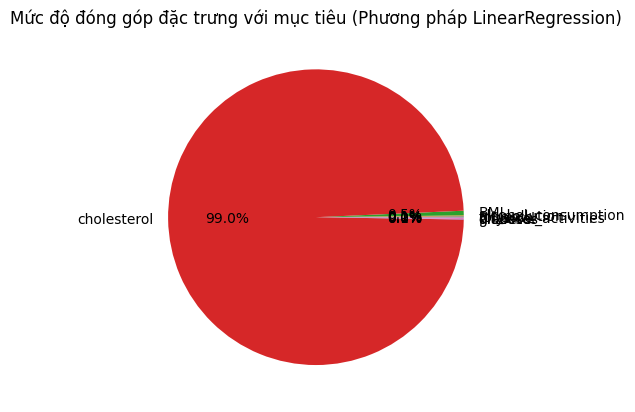

In [120]:
# Vẽ biểu đồ đối với Linear
# Thử vẽ biểu đồ đóng góp
# Biểu đồ này ko có ý nghĩa do ko giải thích được hết dữ liệu
plt.figure()
plt.pie(softmax(coef), labels=X.columns, autopct='%1.1f%%')
plt.title('Mức độ đóng góp đặc trưng với mục tiêu (Phương pháp LinearRegression)')
plt.show()

In [121]:
def run_for_random_forest(X, y):
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
    )

    model.fit(X, y)
    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_

In [122]:
impor = run_for_random_forest(X, y)

MSE: 65.37549757675541
R2: 0.9442980784554437
Feature Importances: [0.11041806 0.03822932 0.37411368 0.09368165 0.0787463  0.01262356
 0.01295469 0.27923274]


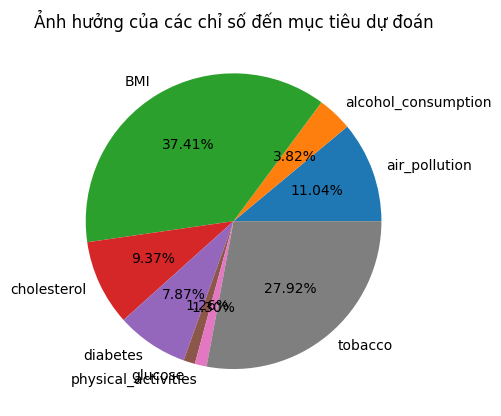

In [123]:
plt.figure()
plt.pie(impor.tolist(), labels=X.columns, autopct='%1.2f%%')
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán')
plt.show()

In [124]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(X.columns, impor.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

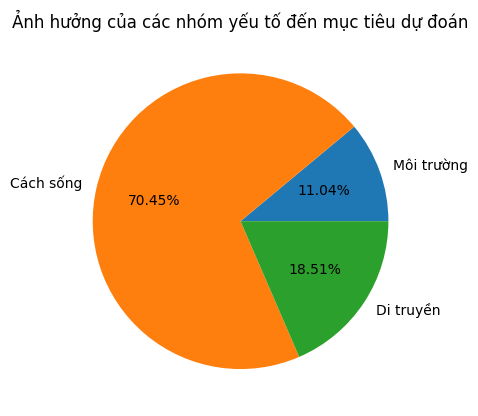

In [125]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Di truyền' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")